In [1]:
import cv2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import random
from glob import glob
import os
from tqdm.notebook import tqdm

import IPython.display as ipd

In [2]:
glob_path = [i for i in glob('Dataset\*\*\*.mp4')]
output_label = [i for i in glob('Dataset\*\*')]

glob_path,output_label

(['Dataset\\Adjectives\\1. loud\\MVI_5177.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5178.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5179.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5257.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5258.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5259.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5335.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5336.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5337.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9289.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9290.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9291.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9368.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9369.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9370.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9448.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9449.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9450.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9534.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9535.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_953

In [3]:
random_video = random.choice(glob_path)
print(random_video.split("\\")[-2:])

cap = cv2.VideoCapture(random_video)
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

['24. School', 'MVI_3535.mp4']
Video Resolution: 1920.0 x 1080.0
FPS: 25.0


In [4]:
cap = cv2.VideoCapture(random_video)
ret, img = cap.read()
print(f'Returned {ret} and img of shape {img.shape}')

Returned True and img of shape (1080, 1920, 3)


In [5]:
def display_cv2_img(img, figsize=(10, 10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis("off")

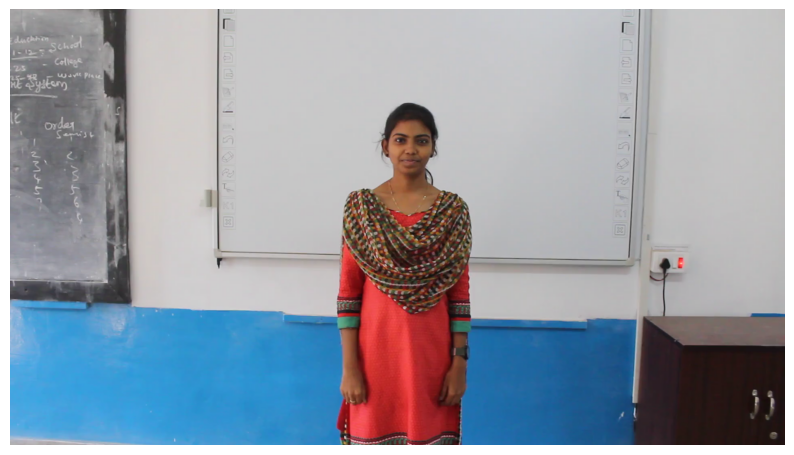

In [6]:
display_cv2_img(img)
cap.release()

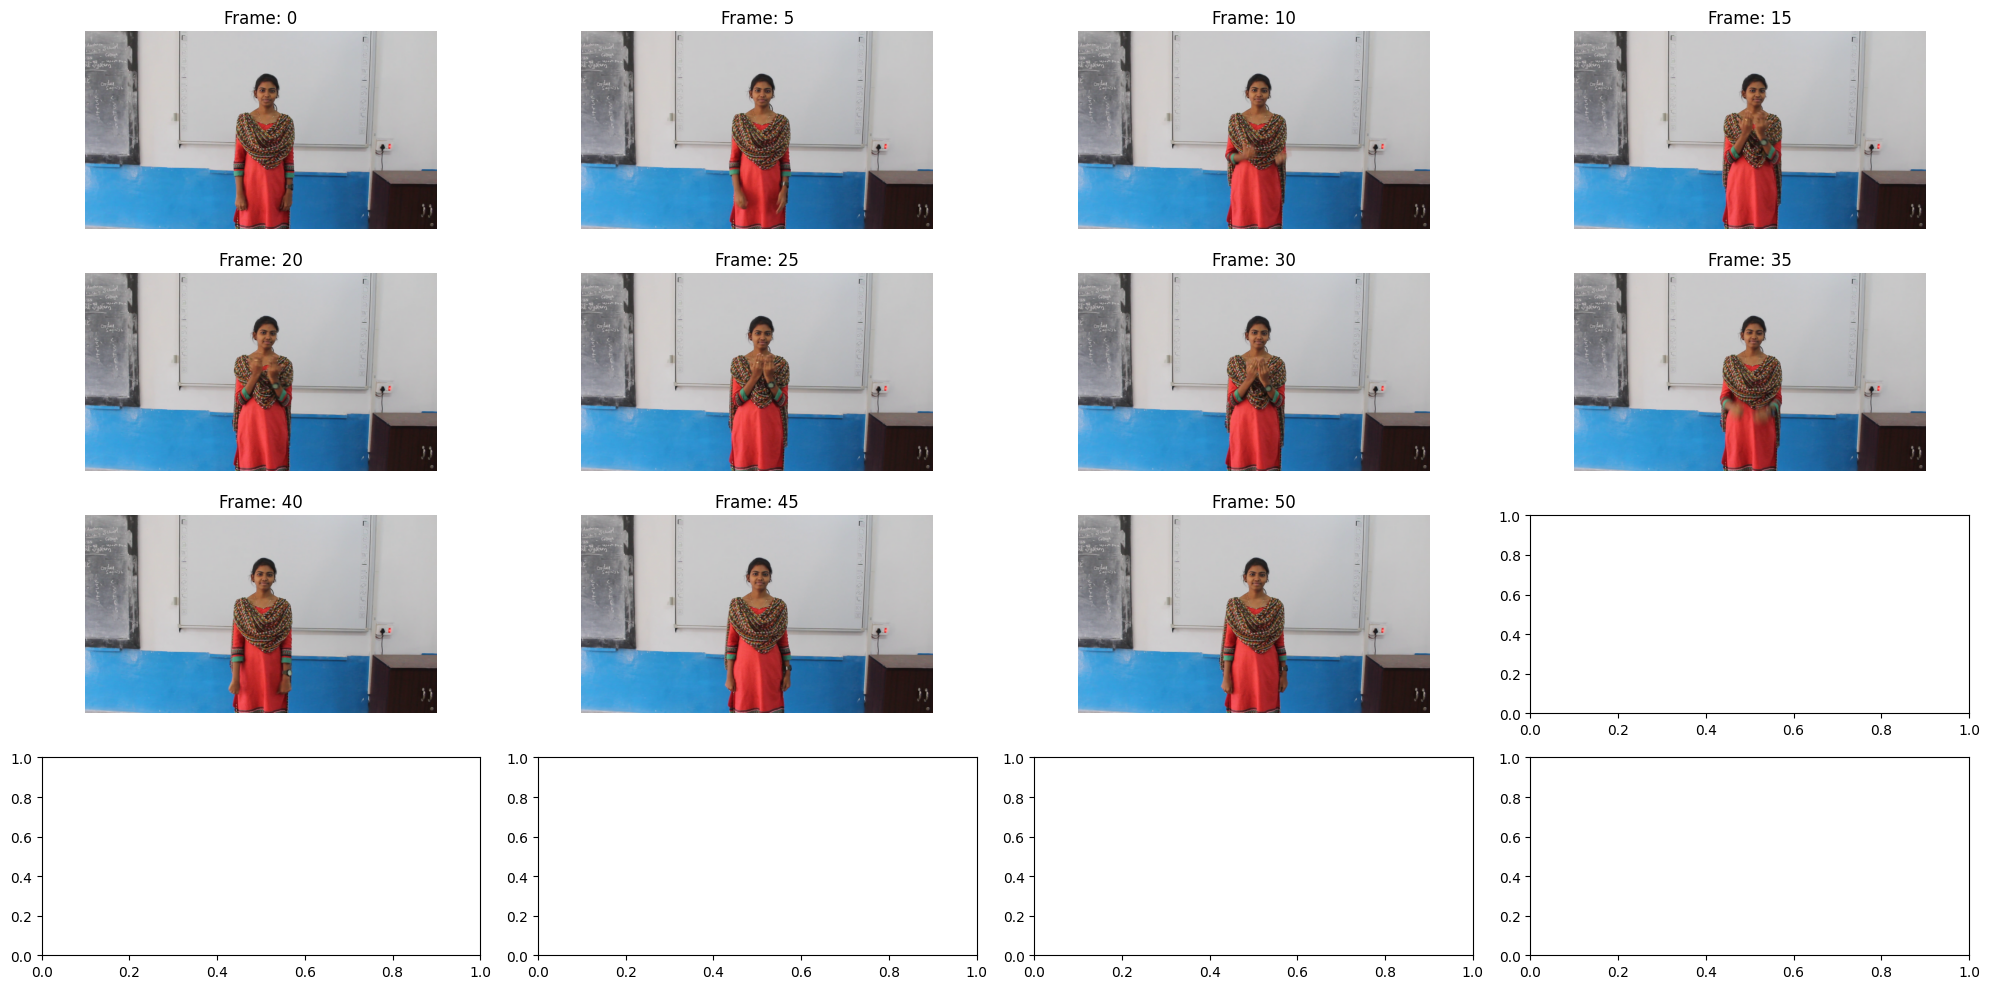

In [9]:
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
axs = axs.flatten()

cap = cv2.VideoCapture(random_video)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


img_idx = 0
for frame in range(n_frames):
    ret, img = cap.read()
    if ret == False:
        break
    if frame % 5 == 0:
        axs[img_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[img_idx].set_title(f'Frame: {frame}')
        axs[img_idx].axis('off')
        img_idx += 1

plt.tight_layout()
plt.show()
cap.release()

## Vedio Augmentaion

1. Org  
2. Centre Crop
3. Flip
4. Upsample
5. Downsample

### Optional (Optional Experimentrs)
6. sharpen 
7. blurred
8. Frame Skipping

### Centre Crop

Saving video at Dataset\Clothes\42. T-Shirt\MVI_4003.mp4_centered.mp4


  0%|          | 0/85 [00:00<?, ?it/s]

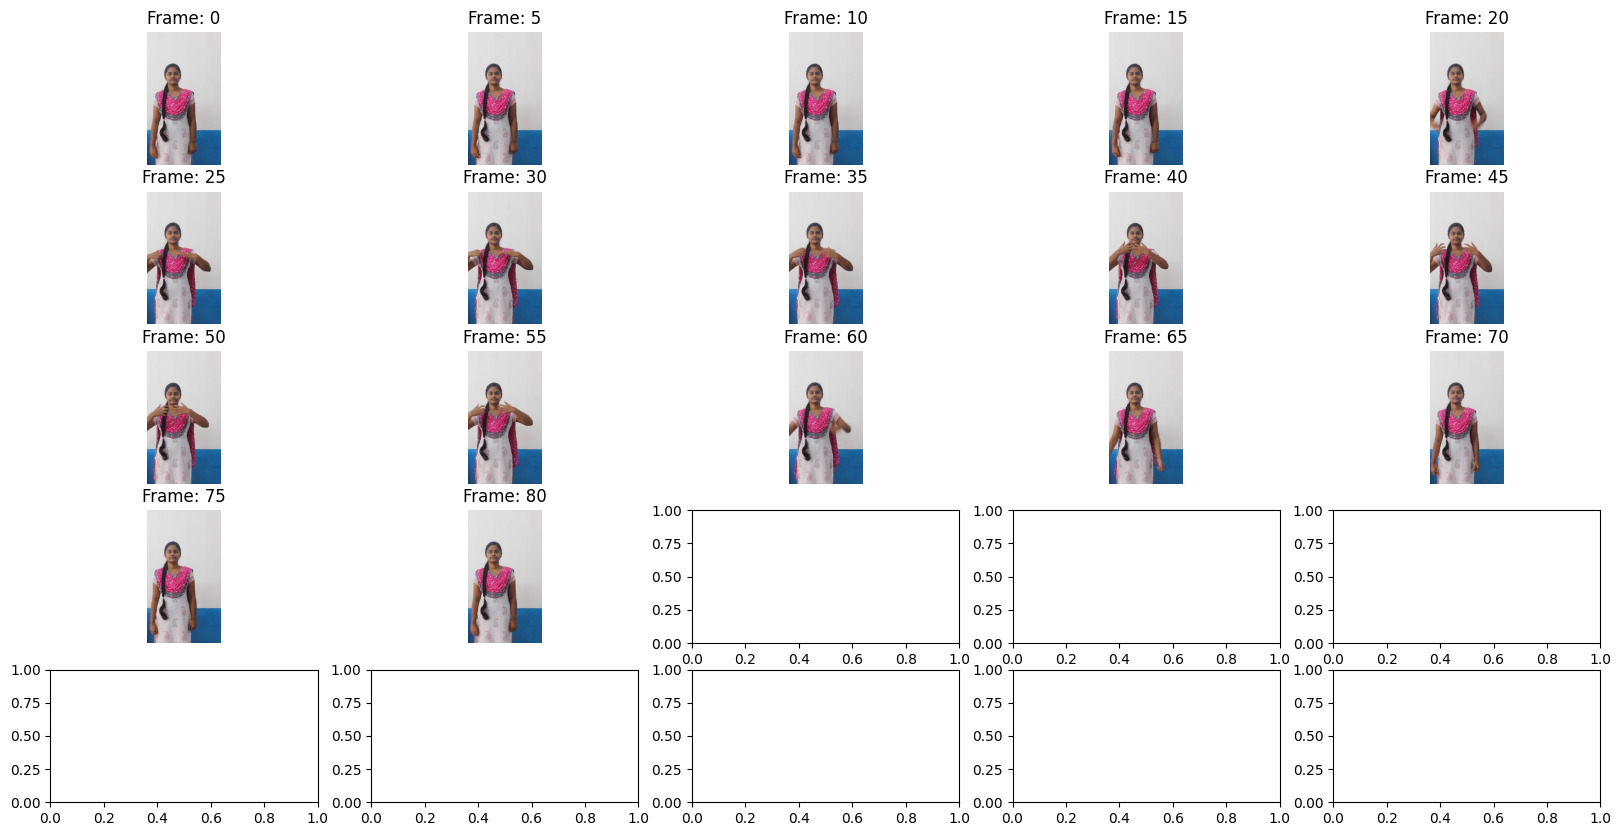

In [41]:
fig, axs = plt.subplots(5, 5, figsize=(20, 10))
axs = axs.flatten()

random_video = random.choice(glob_path)
cap = cv2.VideoCapture(random_video)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

save_path = f"{random_video}_centered.mp4" 
VIDEO_CODEC = "MP4V"
fps = 25
width = 600
height = 1080
print(f"Saving video at {save_path}")
out = cv2.VideoWriter(save_path,
                cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                fps,
                (width, height))


img_idx = 0
for frame in tqdm(range(n_frames)):
    ret, img = cap.read()
    # img = cv2.resize(img, None, fx=0.1, fy=0.1) Downsampling
    img = img[:,700:1300] # Cropping
    
    if ret == False:
        break
    if frame % 5 == 0:
        axs[img_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[img_idx].set_title(f'Frame: {frame}')
        axs[img_idx].axis('off')
        img_idx += 1
    out.write(img)

out.release()
cap.release()


In [ ]:

cap = cv2.VideoCapture(random_video)
n_frames = int(cap.get(cv2.cv2.CAP_PROP_FRAME_COUNT))

